In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import uniform, randint
import warnings
warnings.filterwarnings('ignore')

In [25]:
df = pd.read_csv('/Users/senuja/Jupyter Notebook/Video_Game_Sales_Predictor/results/outputs/Group Pipeline (One-Hot) & DR.csv')

In [26]:
# 3. DEFINE X (FEATURES) AND y (TARGET)
y = df['Sales']
# X is just the SVD components
X = df.drop('Sales', axis=1)

In [27]:
# 4. TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (12524, 2)
Test set shape: (3132, 2)


In [28]:
# 5. HYPERPARAMETER TUNING
print("\nStarting Hyperparameter Tuning for SVR...")
# SVR is sensitive to parameters. 'rbf' is a good kernel for non-linear data.
param_dist = {
    'kernel': ['rbf'],
    'C': uniform(1, 100),       # Regularization parameter
    'gamma': uniform(0.1, 10)   # Kernel coefficient
}

svr = SVR()
random_search = RandomizedSearchCV(
    svr, 
    param_distributions=param_dist, 
    n_iter=50, 
    cv=5, 
    random_state=42, 
    n_jobs=-1,
    scoring='neg_mean_squared_error'
)
random_search.fit(X_train, y_train)

best_svr = random_search.best_estimator_
print(f"Best parameters found: {random_search.best_params_}")


Starting Hyperparameter Tuning for SVR...
Best parameters found: {'C': np.float64(94.9498941564189), 'gamma': np.float64(9.048273504276487), 'kernel': 'rbf'}


In [29]:
# 6. MAKE PREDICTIONS AND EVALUATE
y_pred = best_svr.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n--- Tuned SVR Final Results ---")
print(f"R-squared (R²): {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print("---------------------------------")


--- Tuned SVR Final Results ---
R-squared (R²): 0.0422
Mean Absolute Error (MAE): 0.1616
Root Mean Squared Error (RMSE): 0.2293
---------------------------------


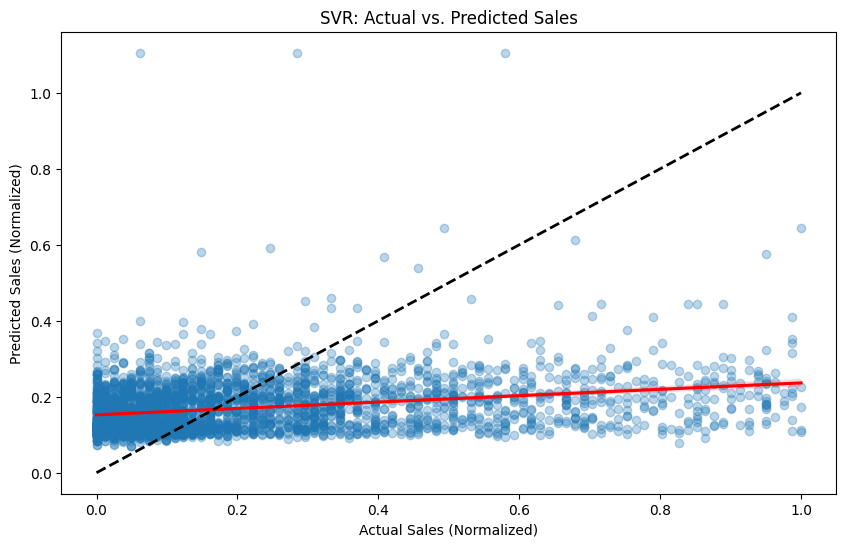

In [30]:
# 7. VISUALIZATION: ACTUAL VS. PREDICTED
# We can't do feature importance because SVD features are uninterpretable
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('SVR: Actual vs. Predicted Sales')
plt.xlabel('Actual Sales (Normalized)')
plt.ylabel('Predicted Sales (Normalized)')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.show()